# Transit Integrated Modeling

Local reproduction of the fixed Colab modeling flow, using `raw_files/integrated_monthly_base.parquet` as the integrated data source.

In [1]:
from __future__ import annotations

import itertools
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)


## Load Local Integrated Data

In [2]:
RAW_FILES_DIR = Path("raw_files")
PARQUET_PATH = RAW_FILES_DIR / "integrated_monthly_base.parquet"

if not PARQUET_PATH.exists():
    raise FileNotFoundError(f"Missing local integrated parquet: {PARQUET_PATH}")

df_integrated = pd.read_parquet(PARQUET_PATH)
df_integrated["date"] = pd.to_datetime(df_integrated["date"], errors="coerce")
df_integrated = df_integrated.sort_values("date").reset_index(drop=True)

print(f"Loaded {PARQUET_PATH}")
print(f"Shape: {df_integrated.shape}")
print(f"Date range: {df_integrated['date'].min()} to {df_integrated['date'].max()}")
df_integrated.tail(5)


Loaded raw_files/integrated_monthly_base.parquet
Shape: (291, 21)
Date range: 2002-01-01 00:00:00 to 2026-03-01 00:00:00


,date,period_end,transit_available_at,transit_series_id,transit_source_name,upt,vrm,vrh,voms,gas_available_at,gas_series_id,gas_source_name,seattle_gas_price_avg,seattle_gas_price_std,weekly_obs_count,inflation_available_at,inflation_series_id,inflation_source_name,cpi_all_items_sa,cpi_core_sa,data_available_at
286,2025-11-01,2025-11-30,2025-12-07,king_county_mb_do_bus,ntd_complete_monthly_ridership_workbook,6034095.0,2569323.0,244071.0,741.0,2025-12-07,seattle_all_grades_gas_price_monthly,eia_seattle_gas_prices,4.4425,0.040862,4.0,2025-12-07,fred_monthly_inflation,fred_inflation,325.063,331.043,2025-12-07
287,2025-12-01,2025-12-31,2026-01-07,king_county_mb_do_bus,ntd_complete_monthly_ridership_workbook,5848180.0,2727319.0,259345.0,745.0,2026-01-07,seattle_all_grades_gas_price_monthly,eia_seattle_gas_prices,4.3004,0.092110,5.0,2026-01-07,fred_monthly_inflation,fred_inflation,326.031,331.814,2026-01-07
288,2026-01-01,2026-01-31,2026-02-07,king_county_mb_do_bus,ntd_complete_monthly_ridership_workbook,6315539.0,2521456.0,245293.0,752.0,2026-02-07,seattle_all_grades_gas_price_monthly,eia_seattle_gas_prices,4.0705,0.050395,4.0,2026-02-07,fred_monthly_inflation,fred_inflation,326.588,332.793,2026-02-07
289,2026-02-01,2026-02-28,2026-03-07,king_county_mb_do_bus,ntd_complete_monthly_ridership_workbook,5912095.0,2318820.0,226557.0,770.0,2026-03-07,seattle_all_grades_gas_price_monthly,eia_seattle_gas_prices,4.3010,0.180877,4.0,2026-03-07,fred_monthly_inflation,fred_inflation,327.460,333.512,2026-03-07
290,2026-03-01,2026-03-31,2026-04-07,king_county_mb_do_bus,ntd_complete_monthly_ridership_workbook,6646228.0,2581034.0,251947.0,776.0,2026-04-07,seattle_all_grades_gas_price_monthly,eia_seattle_gas_prices,5.0632,0.410611,5.0,2026-04-07,fred_monthly_inflation,fred_inflation,330.293,334.165,2026-04-07


## Inspect Model Inputs

In [3]:
model_base_cols = [
    "date",
    "upt",
    "vrm",
    "vrh",
    "voms",
    "seattle_gas_price_avg",
    "seattle_gas_price_std",
    "cpi_all_items_sa",
    "cpi_core_sa",
]

missing_base_cols = [c for c in model_base_cols if c not in df_integrated.columns]
if missing_base_cols:
    raise ValueError(f"Missing required columns: {missing_base_cols}")

df_numeric_features_only = df_integrated[model_base_cols].copy()

display(df_numeric_features_only.head())
display(df_numeric_features_only.tail(10))


,date,upt,vrm,vrh,voms,seattle_gas_price_avg,seattle_gas_price_std,cpi_all_items_sa,cpi_core_sa
0,2002-01-01,6045861.0,2878549.0,216788.0,931.0,NaN,NaN,177.7,188.7
1,2002-02-01,5406135.0,2558164.0,192360.0,931.0,NaN,NaN,178.0,189.1
2,2002-03-01,5999230.0,2840121.0,213519.0,931.0,NaN,NaN,178.5,189.2
3,2002-04-01,6058398.0,2855047.0,213860.0,931.0,NaN,NaN,179.3,189.7
4,2002-05-01,6134503.0,2899399.0,217418.0,931.0,NaN,NaN,179.5,190.0


,date,upt,vrm,vrh,voms,seattle_gas_price_avg,seattle_gas_price_std,cpi_all_items_sa,cpi_core_sa
281,2025-06-01,6688867.0,2630448.0,250100.0,739.0,4.56860,0.037534,321.435,327.658
282,2025-07-01,6716230.0,2727319.0,259345.0,748.0,4.55450,0.023812,322.169,328.682
283,2025-08-01,6629625.0,2697388.0,256443.0,740.0,4.54525,0.017347,323.291,329.700
284,2025-09-01,6597525.0,2630448.0,250100.0,745.0,4.67860,0.104777,324.245,330.418
285,2025-10-01,7027582.0,2758513.0,262473.0,742.0,4.63075,0.054537,NaN,NaN
286,2025-11-01,6034095.0,2569323.0,244071.0,741.0,4.44250,0.040862,325.063,331.043
287,2025-12-01,5848180.0,2727319.0,259345.0,745.0,4.30040,0.092110,326.031,331.814
288,2026-01-01,6315539.0,2521456.0,245293.0,752.0,4.07050,0.050395,326.588,332.793
289,2026-02-01,5912095.0,2318820.0,226557.0,770.0,4.30100,0.180877,327.460,333.512
290,2026-03-01,6646228.0,2581034.0,251947.0,776.0,5.06320,0.410611,330.293,334.165


In [4]:
nan_summary = df_numeric_features_only.isna().sum().rename("null_count").to_frame()
nan_summary["null_pct"] = nan_summary["null_count"] / len(df_numeric_features_only)
display(nan_summary)

rows_with_required_nulls = df_numeric_features_only[df_numeric_features_only.isna().any(axis=1)].copy()
display(rows_with_required_nulls)


,null_count,null_pct
date,0,0.000000
upt,0,0.000000
vrm,0,0.000000
vrh,0,0.000000
voms,0,0.000000
seattle_gas_price_avg,16,0.054983
seattle_gas_price_std,16,0.054983
cpi_all_items_sa,1,0.003436
cpi_core_sa,1,0.003436


,date,upt,vrm,vrh,voms,seattle_gas_price_avg,seattle_gas_price_std,cpi_all_items_sa,cpi_core_sa
0,2002-01-01,6045861.0,2878549.0,216788.0,931.0,NaN,NaN,177.7,188.7
1,2002-02-01,5406135.0,2558164.0,192360.0,931.0,NaN,NaN,178.0,189.1
2,2002-03-01,5999230.0,2840121.0,213519.0,931.0,NaN,NaN,178.5,189.2
3,2002-04-01,6058398.0,2855047.0,213860.0,931.0,NaN,NaN,179.3,189.7
4,2002-05-01,6134503.0,2899399.0,217418.0,931.0,NaN,NaN,179.5,190.0
5,2002-06-01,5654916.0,2714672.0,204263.0,931.0,NaN,NaN,179.6,190.2
6,2002-07-01,5946469.0,2875414.0,215763.0,931.0,NaN,NaN,180.0,190.5
7,2002-08-01,5999146.0,2888733.0,216836.0,931.0,NaN,NaN,180.5,191.1
8,2002-09-01,5571149.0,2681698.0,203327.0,931.0,NaN,NaN,180.8,191.3
9,2002-10-01,6024277.0,2616778.0,225522.0,931.0,NaN,NaN,181.2,191.5


## Fixed Notebook Trim + Exogenous Imputation


In [5]:
# Fixed notebook behavior: trim the 16 leading rows where gas inputs are unavailable.
# After that, fill interior/trailing exogenous gaps before feature engineering.
def fill_trailing_with_recent_trend(series: pd.Series, window: int = 5) -> pd.Series:
    filled = series.copy()

    while filled.isna().any():
        missing_positions = np.flatnonzero(filled.isna().to_numpy())
        pos = missing_positions[0]

        # Interior gaps are handled by interpolation; this branch is only for trailing gaps.
        if pos < len(filled) - 1 and filled.iloc[pos + 1:].notna().any():
            break

        history = filled.iloc[:pos].dropna().tail(window)
        if len(history) >= 2:
            x = np.arange(len(history), dtype=float)
            slope, intercept = np.polyfit(x, history.to_numpy(dtype=float), 1)
            filled.iloc[pos] = intercept + slope * len(history)
        elif len(history) == 1:
            filled.iloc[pos] = history.iloc[-1]
        else:
            break

    return filled


def impute_exogenous_monthly_values(df: pd.DataFrame, cols: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    working = df.copy()
    imputation_records = []

    for col in cols:
        if col not in working.columns:
            continue

        original = working[col].copy()
        original_missing = original.isna()

        working[f"{col}_was_imputed"] = 0
        working[f"{col}_imputed_interpolated"] = 0
        working[f"{col}_imputed_trailing_trend"] = 0

        interpolated = original.interpolate(method="linear", limit_area="inside")
        interpolated_positions = original_missing & interpolated.notna()

        trended = fill_trailing_with_recent_trend(interpolated, window=5)
        trended_positions = original_missing & interpolated.isna() & trended.notna()

        working[col] = trended
        working.loc[original_missing & working[col].notna(), f"{col}_was_imputed"] = 1
        working.loc[interpolated_positions, f"{col}_imputed_interpolated"] = 1
        working.loc[trended_positions, f"{col}_imputed_trailing_trend"] = 1

        for idx in working.index[original_missing & working[col].notna()]:
            method = "linear_interpolation_between_observed_months"
            if trended_positions.loc[idx]:
                method = "five_month_recent_trend_projection"

            imputation_records.append({
                "date": working.loc[idx, "date"],
                "column": col,
                "method": method,
                "imputed_value": working.loc[idx, col],
            })

    return working, pd.DataFrame(imputation_records)


exogenous_cols_to_impute = [
    "seattle_gas_price_avg",
    "seattle_gas_price_std",
    "cpi_all_items_sa",
    "cpi_core_sa",
]

df_numeric_features_only = df_numeric_features_only.iloc[16:].copy()
print(f"Rows after fixed-notebook trim: {len(df_numeric_features_only)}")

df_numeric_features_only_trimmed, exogenous_imputation_log = impute_exogenous_monthly_values(
    df_numeric_features_only,
    exogenous_cols_to_impute,
)

print(f"Exogenous imputations applied: {len(exogenous_imputation_log)}")
display(exogenous_imputation_log)

display(df_numeric_features_only_trimmed.head())
display(df_numeric_features_only_trimmed.isna().sum().rename("null_count_after_trim_and_impute").to_frame())
display(df_numeric_features_only_trimmed[df_numeric_features_only_trimmed.isna().any(axis=1)])


Rows after fixed-notebook trim: 275
Exogenous imputations applied: 2


,date,column,method,imputed_value
0,2025-10-01,cpi_all_items_sa,linear_interpolation_between_observed_months,324.6540
1,2025-10-01,cpi_core_sa,linear_interpolation_between_observed_months,330.7305


,date,upt,vrm,vrh,voms,seattle_gas_price_avg,seattle_gas_price_std,cpi_all_items_sa,cpi_core_sa,seattle_gas_price_avg_was_imputed,seattle_gas_price_avg_imputed_interpolated,seattle_gas_price_avg_imputed_trailing_trend,seattle_gas_price_std_was_imputed,seattle_gas_price_std_imputed_interpolated,seattle_gas_price_std_imputed_trailing_trend,cpi_all_items_sa_was_imputed,cpi_all_items_sa_imputed_interpolated,cpi_all_items_sa_imputed_trailing_trend,cpi_core_sa_was_imputed,cpi_core_sa_imputed_interpolated,cpi_core_sa_imputed_trailing_trend
16,2003-05-01,6018871.0,2893190.0,217503.0,931.0,1.57400,0.000000,182.9,192.9,0,0,0,0,0,0,0,0,0,0,0,0
17,2003-06-01,5766180.0,2829145.0,212087.0,931.0,1.59080,0.026985,183.1,193.0,0,0,0,0,0,0,0,0,0,0,0,0
18,2003-07-01,5946970.0,2938717.0,220105.0,931.0,1.62175,0.016174,183.7,193.4,0,0,0,0,0,0,0,0,0,0,0,0
19,2003-08-01,5828996.0,2882080.0,216402.0,931.0,1.77975,0.158401,184.5,193.6,0,0,0,0,0,0,0,0,0,0,0,0
20,2003-09-01,5715720.0,2847550.0,213518.0,931.0,1.88740,0.079226,185.1,193.7,0,0,0,0,0,0,0,0,0,0,0,0


,null_count_after_trim_and_impute
date,0
upt,0
vrm,0
vrh,0
voms,0
seattle_gas_price_avg,0
seattle_gas_price_std,0
cpi_all_items_sa,0
cpi_core_sa,0
seattle_gas_price_avg_was_imputed,0


,date,upt,vrm,vrh,voms,seattle_gas_price_avg,seattle_gas_price_std,cpi_all_items_sa,cpi_core_sa,seattle_gas_price_avg_was_imputed,seattle_gas_price_avg_imputed_interpolated,seattle_gas_price_avg_imputed_trailing_trend,seattle_gas_price_std_was_imputed,seattle_gas_price_std_imputed_interpolated,seattle_gas_price_std_imputed_trailing_trend,cpi_all_items_sa_was_imputed,cpi_all_items_sa_imputed_interpolated,cpi_all_items_sa_imputed_trailing_trend,cpi_core_sa_was_imputed,cpi_core_sa_imputed_interpolated,cpi_core_sa_imputed_trailing_trend


## Feature Engineering

In [6]:
def add_time_and_regime_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.to_period("M").dt.to_timestamp()
    df = df.sort_values("date").reset_index(drop=True)

    df["time_index_months"] = np.arange(len(df))
    df["month_num"] = df["date"].dt.month

    df["month_sin"] = np.sin(2 * np.pi * df["month_num"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month_num"] / 12)

    covid_start = pd.Timestamp("2020-03-01")
    post_covid_start = pd.Timestamp("2021-03-01")

    df["is_covid_disruption"] = (
        (df["date"] >= covid_start) & (df["date"] < post_covid_start)
    ).astype(int)

    df["is_post_covid"] = (df["date"] >= post_covid_start).astype(int)

    df["months_since_covid_impact"] = np.where(
        df["date"] >= covid_start,
        (
            (df["date"].dt.year - covid_start.year) * 12
            + (df["date"].dt.month - covid_start.month)
        ),
        0
    )

    return df


def add_lagged_features_for_group(
    df: pd.DataFrame,
    cols: list[str],
    lags: list[int],
    rolling_windows: list[int],
    diff_lags: list[int],
    add_yoy_diff: bool = True,
    add_yoy_pct: bool = False,
    add_rollstd: bool = True,
) -> pd.DataFrame:
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.to_period("M").dt.to_timestamp()
    df = df.sort_values("date").reset_index(drop=True)

    for col in cols:
        if col not in df.columns:
            raise ValueError(f"Column not found in dataframe: {col}")

        # raw lag values
        for lag in lags:
            df[f"{col}_lag{lag}"] = df[col].shift(lag)

        # lagged differences
        for lag in diff_lags:
            df[f"{col}_diff_lag{lag}"] = df[col].shift(lag) - df[col].shift(lag + 1)

        # rolling summaries from past data only
        lagged = df[col].shift(1)

        for window in rolling_windows:
            df[f"{col}_rollmean_{window}"] = lagged.rolling(window).mean()
            if add_rollstd:
                df[f"{col}_rollstd_{window}"] = lagged.rolling(window).std()

        # YoY features
        if add_yoy_diff:
            df[f"{col}_yoy_diff"] = df[col].shift(1) - df[col].shift(13)

        if add_yoy_pct:
            prev_year = df[col].shift(13)
            df[f"{col}_yoy_pct"] = np.where(
                prev_year != 0,
                (df[col].shift(1) - prev_year) / prev_year,
                np.nan
            )

    return df


def add_target_horizon(
    df: pd.DataFrame,
    target_col: str,
    horizon: int,
    date_col: str = "date",
) -> pd.DataFrame:
    df = df.copy()
    df[date_col] = pd.to_datetime(
        df[date_col],
        errors="coerce"
    ).dt.to_period("M").dt.to_timestamp()

    df = df.sort_values(date_col).reset_index(drop=True)

    df[f"{target_col}_target_h{horizon}"] = df[target_col].shift(-horizon)

    df[f"target_date_h{horizon}"] = df[date_col] + pd.DateOffset(months=horizon)
    df[f"target_month_num_h{horizon}"] = df[f"target_date_h{horizon}"].dt.month

    df[f"target_month_sin_h{horizon}"] = np.sin(
        2 * np.pi * df[f"target_month_num_h{horizon}"] / 12
    )
    df[f"target_month_cos_h{horizon}"] = np.cos(
        2 * np.pi * df[f"target_month_num_h{horizon}"] / 12
    )

    return df


def build_feature_table(
    df: pd.DataFrame,
    target_col: str = "upt",
    horizon: int = 3,
) -> pd.DataFrame:
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.to_period("M").dt.to_timestamp()
    df = df.sort_values("date").reset_index(drop=True)

    df = add_time_and_regime_features(df)

    upt_cols = ["upt"]

    service_cols = [
        "vrm",
        "vrh",
        "voms",
    ]

    exogenous_cols = [
        "seattle_gas_price_avg",
        "seattle_gas_price_std",
        "cpi_all_items_sa",
        "cpi_core_sa",
    ]

    service_cols = [col for col in service_cols if col in df.columns]
    exogenous_cols = [col for col in exogenous_cols if col in df.columns]

    # Dense memory for UPT
    df = add_lagged_features_for_group(
        df,
        cols=upt_cols,
        lags=list(range(1, 13)) + [18, 24],
        rolling_windows=[3, 6],
        diff_lags=[1, 2, 3],
        add_yoy_diff=True,
        add_yoy_pct=False,
        add_rollstd=True,
    )

    # Lighter lag set for service variables
    df = add_lagged_features_for_group(
        df,
        cols=service_cols,
        lags=[1, 3, 6, 12],
        rolling_windows=[3, 6],
        diff_lags=[1, 3],
        add_yoy_diff=True,
        add_yoy_pct=False,
        add_rollstd=False,
    )

    # Recent-focused lag set for exogenous variables
    df = add_lagged_features_for_group(
        df,
        cols=exogenous_cols,
        lags=[1, 2, 3, 6, 12],
        rolling_windows=[3],
        diff_lags=[1, 3],
        add_yoy_diff=True,
        add_yoy_pct=False,
        add_rollstd=False,
    )

    df = add_target_horizon(
        df,
        target_col=target_col,
        horizon=horizon,
        date_col="date",
    )

    return df


In [7]:
df_feature_base = df_numeric_features_only_trimmed.copy()

df_feature_base["date"] = pd.to_datetime(
    df_feature_base["date"],
    errors="coerce"
).dt.to_period("M").dt.to_timestamp()

feature_table_h3 = build_feature_table(
    df=df_feature_base,
    target_col="upt",
    horizon=3,
)

feature_table_h3.head(20)

#printing names of columns in feature_table_h3 that contain the "upt"
for col in feature_table_h3.columns:
    if "upt" in col:
        print(col)


upt
is_covid_disruption
upt_lag1
upt_lag2
upt_lag3
upt_lag4
upt_lag5
upt_lag6
upt_lag7
upt_lag8
upt_lag9
upt_lag10
upt_lag11
upt_lag12
upt_lag18
upt_lag24
upt_diff_lag1
upt_diff_lag2
upt_diff_lag3
upt_rollmean_3
upt_rollstd_3
upt_rollmean_6
upt_rollstd_6
upt_yoy_diff
upt_target_h3


## Model Evaluation Helpers

In [9]:
def add_seasonal_naive_proxy(
    df: pd.DataFrame,
    target_col: str,
    seasonal_periods: int = 12,
) -> pd.DataFrame:
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.to_period("M").dt.to_timestamp()
    df = df.sort_values("date").reset_index(drop=True)

    df["seasonal_naive_proxy"] = df[target_col].shift(seasonal_periods)
    return df

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def directional_accuracy(actual, pred):
    actual_diff = np.sign(np.diff(actual))
    pred_diff = np.sign(np.diff(pred))
    return (actual_diff == pred_diff).mean() if len(actual_diff) > 0 else np.nan


def run_xgb_experiment(
    df: pd.DataFrame,
    feature_cols: list[str],
    params: dict,
    target_col: str = "upt_target_h3",
    split_date: str = "2025-01-01",
    valid_start_date: Optional[str] = None,
    mode: str = "raw",   # "raw" or "residual"
):
    work = df.copy()
    work["date"] = pd.to_datetime(work["date"], errors="coerce").dt.to_period("M").dt.to_timestamp()
    work = work.sort_values("date").reset_index(drop=True)

    needed_cols = ["date", target_col] + [c for c in feature_cols if c in work.columns]
    work = work[needed_cols].copy()

    # Correctly aligned seasonal naive baseline for the target itself
    work = add_seasonal_naive_proxy(work, target_col=target_col, seasonal_periods=12)

    # Drop rows only after seasonal proxy exists
    if mode == "raw":
        work = work.dropna(subset=feature_cols + [target_col]).copy()
    elif mode == "residual":
        work = work.dropna(subset=feature_cols + [target_col, "seasonal_naive_proxy"]).copy()
    else:
        raise ValueError("mode must be 'raw' or 'residual'")

    split_date = pd.Timestamp(split_date)

    train_df = work[work["date"] < split_date].copy()
    valid_df = work[work["date"] >= split_date].copy()

    # Optional inner validation start if you want a 2024-only validation like old notebook
    if valid_start_date is not None:
        valid_start_date = pd.Timestamp(valid_start_date)
        train_full = train_df.copy()
        valid_df = train_full[train_full["date"] >= valid_start_date].copy()
        train_df = train_full[train_full["date"] < valid_start_date].copy()

    X_train = train_df[feature_cols]
    X_valid = valid_df[feature_cols]

    if mode == "raw":
        y_train = train_df[target_col]
        y_valid = valid_df[target_col]
    else:
        y_train = train_df[target_col] - train_df["seasonal_naive_proxy"]
        y_valid = valid_df[target_col] - valid_df["seasonal_naive_proxy"]

    model = XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        **params,
    )
    model.fit(X_train, y_train)

    pred_valid = model.predict(X_valid)

    if mode == "residual":
        pred_valid = valid_df["seasonal_naive_proxy"].values + pred_valid

    actual_valid = valid_df[target_col].values
    naive_valid = valid_df["seasonal_naive_proxy"].values

    return {
        "feature_cols": feature_cols,
        "n_features": len(feature_cols),
        "mode": mode,
        "n_train": len(train_df),
        "n_valid": len(valid_df),
        "mae_valid": mean_absolute_error(actual_valid, pred_valid),
        "rmse_valid": mean_squared_error(actual_valid, pred_valid) ** 0.5,
        "r2_valid": r2_score(actual_valid, pred_valid),
        "diracc_valid": directional_accuracy(actual_valid, pred_valid),
        "mae_naive_valid": mean_absolute_error(actual_valid, naive_valid),
        "rmse_naive_valid": mean_squared_error(actual_valid, naive_valid) ** 0.5,
        "pred_valid": pred_valid,
        "actual_valid": actual_valid,
        "naive_valid": naive_valid,
        "valid_dates": valid_df["date"].values,
        "model": model,
    }


## Fixed Feature Families

In [10]:
feature_families = {
    "history_core": [
        "upt_lag1",
        "upt_lag2",
        "upt_lag3",
        "upt_lag6",
        "upt_lag12",
        "upt_lag18",
        "upt_lag24",
    ],

    "history_recent_deltas": [
        "upt_diff_lag1",
        "upt_diff_lag2",
        "upt_diff_lag3",
    ],

    "history_rolls": [
        "upt_rollmean_3",
        "upt_rollstd_3",
        "upt_rollmean_6",
        "upt_rollstd_6",
    ],

    "history_yoy": [
        "upt_yoy_diff",
    ],

    "seasonality": [
        "month_sin",
        "month_cos",
        "target_month_sin_h3",
        "target_month_cos_h3",
    ],

    "regime": [
        "is_covid_disruption",
        "is_post_covid",
        "months_since_covid_impact",
    ],

    "time_trend": [
        "time_index_months",
    ],

    "gas": [
        "seattle_gas_price_avg_lag1",
        "seattle_gas_price_avg_lag2",
        "seattle_gas_price_avg_lag3",
        "seattle_gas_price_avg_lag6",
        "seattle_gas_price_avg_lag12",
        "seattle_gas_price_avg_diff_lag1",
        "seattle_gas_price_avg_diff_lag3",
        "seattle_gas_price_avg_rollmean_3",
        "seattle_gas_price_avg_yoy_diff",
        "seattle_gas_price_std_lag1",
        "seattle_gas_price_std_lag2",
        "seattle_gas_price_std_lag3",
        "seattle_gas_price_std_lag6",
        "seattle_gas_price_std_lag12",
        "seattle_gas_price_std_diff_lag1",
        "seattle_gas_price_std_diff_lag3",
        "seattle_gas_price_std_rollmean_3",
        "seattle_gas_price_std_yoy_diff",
    ],

    "cpi": [
        "cpi_all_items_sa_lag1",
        "cpi_all_items_sa_lag2",
        "cpi_all_items_sa_lag3",
        "cpi_all_items_sa_lag6",
        "cpi_all_items_sa_lag12",
        "cpi_all_items_sa_diff_lag1",
        "cpi_all_items_sa_diff_lag3",
        "cpi_all_items_sa_rollmean_3",
        "cpi_all_items_sa_yoy_diff",
        "cpi_core_sa_lag1",
        "cpi_core_sa_lag2",
        "cpi_core_sa_lag3",
        "cpi_core_sa_lag6",
        "cpi_core_sa_lag12",
        "cpi_core_sa_diff_lag1",
        "cpi_core_sa_diff_lag3",
        "cpi_core_sa_rollmean_3",
        "cpi_core_sa_yoy_diff",
    ],

    "service": [
        "vrm_lag1",
        "vrm_lag3",
        "vrm_lag6",
        "vrm_lag12",
        "vrm_diff_lag1",
        "vrm_diff_lag3",
        "vrm_rollmean_3",
        "vrm_rollmean_6",
        "vrm_yoy_diff",
        "vrh_lag1",
        "vrh_lag3",
        "vrh_lag6",
        "vrh_lag12",
        "vrh_diff_lag1",
        "vrh_diff_lag3",
        "vrh_rollmean_3",
        "vrh_rollmean_6",
        "vrh_yoy_diff",
        "voms_lag1",
        "voms_lag3",
        "voms_lag6",
        "voms_lag12",
        "voms_diff_lag1",
        "voms_diff_lag3",
        "voms_rollmean_3",
        "voms_rollmean_6",
        "voms_yoy_diff",
    ],
}

feature_set_library = {
    "history_only": (
        feature_families["history_core"]
        + feature_families["seasonality"]
    ),

    "history_recent": (
        feature_families["history_core"]
        + feature_families["history_recent_deltas"]
        + feature_families["seasonality"]
    ),

    "history_rolls": (
        feature_families["history_core"]
        + feature_families["history_recent_deltas"]
        + feature_families["history_rolls"]
        + feature_families["seasonality"]
    ),

    "history_full": (
        feature_families["history_core"]
        + feature_families["history_recent_deltas"]
        + feature_families["history_rolls"]
        + feature_families["history_yoy"]
        + feature_families["seasonality"]
    ),

    "history_regime": (
        feature_families["history_core"]
        + feature_families["history_recent_deltas"]
        + feature_families["history_rolls"]
        + feature_families["history_yoy"]
        + feature_families["seasonality"]
        + feature_families["regime"]
    ),

    "history_regime_time": (
        feature_families["history_core"]
        + feature_families["history_recent_deltas"]
        + feature_families["history_rolls"]
        + feature_families["history_yoy"]
        + feature_families["seasonality"]
        + feature_families["regime"]
        + feature_families["time_trend"]
    ),

    "history_regime_gas": (
        feature_families["history_core"]
        + feature_families["history_recent_deltas"]
        + feature_families["history_rolls"]
        + feature_families["history_yoy"]
        + feature_families["seasonality"]
        + feature_families["regime"]
        + feature_families["gas"]
    ),

    "history_regime_cpi": (
        feature_families["history_core"]
        + feature_families["history_recent_deltas"]
        + feature_families["history_rolls"]
        + feature_families["history_yoy"]
        + feature_families["seasonality"]
        + feature_families["regime"]
        + feature_families["cpi"]
    ),

    "history_regime_service": (
        feature_families["history_core"]
        + feature_families["history_recent_deltas"]
        + feature_families["history_rolls"]
        + feature_families["history_yoy"]
        + feature_families["seasonality"]
        + feature_families["regime"]
        + feature_families["service"]
    ),

    "history_regime_gas_cpi": (
        feature_families["history_core"]
        + feature_families["history_recent_deltas"]
        + feature_families["history_rolls"]
        + feature_families["history_yoy"]
        + feature_families["seasonality"]
        + feature_families["regime"]
        + feature_families["gas"]
        + feature_families["cpi"]
    ),

    "history_regime_gas_service": (
        feature_families["history_core"]
        + feature_families["history_recent_deltas"]
        + feature_families["history_rolls"]
        + feature_families["history_yoy"]
        + feature_families["seasonality"]
        + feature_families["regime"]
        + feature_families["gas"]
        + feature_families["service"]
    ),

    "history_regime_cpi_service": (
        feature_families["history_core"]
        + feature_families["history_recent_deltas"]
        + feature_families["history_rolls"]
        + feature_families["history_yoy"]
        + feature_families["seasonality"]
        + feature_families["regime"]
        + feature_families["cpi"]
        + feature_families["service"]
    ),

    "history_regime_all_exog": (
        feature_families["history_core"]
        + feature_families["history_recent_deltas"]
        + feature_families["history_rolls"]
        + feature_families["history_yoy"]
        + feature_families["seasonality"]
        + feature_families["regime"]
        + feature_families["gas"]
        + feature_families["cpi"]
        + feature_families["service"]
    ),

    "history_regime_time_all_exog": (
        feature_families["history_core"]
        + feature_families["history_recent_deltas"]
        + feature_families["history_rolls"]
        + feature_families["history_yoy"]
        + feature_families["seasonality"]
        + feature_families["regime"]
        + feature_families["time_trend"]
        + feature_families["gas"]
        + feature_families["cpi"]
        + feature_families["service"]
    ),
}

feature_set_library = {
    name: list(dict.fromkeys(cols))
    for name, cols in feature_set_library.items()
}


In [11]:
feature_family_counts = pd.DataFrame(
    [
        {
            "feature_family_name": name,
            "requested_features": len(cols),
            "available_features": sum(c in feature_table_h3.columns for c in cols),
            "missing_features": [c for c in cols if c not in feature_table_h3.columns],
        }
        for name, cols in feature_set_library.items()
    ]
)

display(feature_family_counts)


,feature_family_name,requested_features,available_features,missing_features
0,history_only,11,11,[]
1,history_recent,14,14,[]
2,history_rolls,18,18,[]
3,history_full,19,19,[]
4,history_regime,22,22,[]
5,history_regime_time,23,23,[]
6,history_regime_gas,40,40,[]
7,history_regime_cpi,40,40,[]
8,history_regime_service,49,49,[]
9,history_regime_gas_cpi,58,58,[]


## Main Feature Family Grid

In [12]:
target_col = "upt_target_h3"

param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [3, 4],
    "learning_rate": [0.05, 0.10],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
    "min_child_weight": [1, 3],
}

grid_keys = list(param_grid.keys())
grid_values = list(param_grid.values())
param_combos = [dict(zip(grid_keys, vals)) for vals in itertools.product(*grid_values)]

results = []

for feature_family_name, feature_cols_raw in feature_set_library.items():
    feature_cols = [c for c in feature_cols_raw if c in feature_table_h3.columns]

    for mode in ["raw", "residual"]:
        for params in param_combos:
            out = run_xgb_experiment(
                df=feature_table_h3,
                feature_cols=feature_cols,
                params=params,
                target_col=target_col,
                split_date="2025-01-01",
                mode=mode,
            )

            results.append({
                "feature_family_name": feature_family_name,
                "mode": mode,
                "n_features": out["n_features"],
                "n_train": out["n_train"],
                "n_valid": out["n_valid"],
                **params,
                "mae_valid": out["mae_valid"],
                "rmse_valid": out["rmse_valid"],
                "r2_valid": out["r2_valid"],
                "diracc_valid": out["diracc_valid"],
                "mae_naive_valid": out["mae_naive_valid"],
                "rmse_naive_valid": out["rmse_naive_valid"],
                "mae_improvement_vs_naive": out["mae_naive_valid"] - out["mae_valid"],
                "rmse_improvement_vs_naive": out["rmse_naive_valid"] - out["rmse_valid"],
            })

results_df = pd.DataFrame(results).sort_values("rmse_valid").reset_index(drop=True)
results_df.head(20)

summary_by_family_mode = (
    results_df.groupby(["feature_family_name", "mode"])
    .agg(
        best_rmse=("rmse_valid", "min"),
        best_mae=("mae_valid", "min"),
        best_r2=("r2_valid", "max"),
        best_diracc=("diracc_valid", "max"),
        best_rmse_improvement_vs_naive=("rmse_improvement_vs_naive", "max"),
        best_mae_improvement_vs_naive=("mae_improvement_vs_naive", "max"),
        avg_rmse=("rmse_valid", "mean"),
        avg_mae=("mae_valid", "mean"),
    )
    .sort_values("best_rmse")
    .reset_index()
)

summary_by_family_mode


,feature_family_name,mode,best_rmse,best_mae,best_r2,best_diracc,best_rmse_improvement_vs_naive,best_mae_improvement_vs_naive,avg_rmse,avg_mae
0,history_regime_cpi,residual,205818.833361,174627.765625,0.712242,0.909091,249392.438345,202165.151042,256314.049772,213298.661092
1,history_only,residual,221470.077059,193566.539062,0.666813,0.909091,233741.194646,183226.377604,257203.685610,218529.882812
2,history_regime_time,residual,221764.884480,191752.686198,0.665926,0.909091,233446.387225,185040.230469,251364.808582,215284.436588
3,history_recent,residual,236840.255848,197367.494792,0.618962,0.909091,218371.015857,179425.421875,269282.479972,222494.146484
4,history_regime_cpi_service,residual,240852.889959,193927.558594,0.605941,0.909091,214358.381746,182865.358073,274992.600693,225274.944010
5,history_rolls,residual,253990.406414,196891.903646,0.561780,1.000000,201220.865291,179901.013021,275689.056897,218875.997884
6,history_regime_service,residual,254723.703708,215286.821615,0.559246,0.909091,200487.567997,161506.095052,278388.730715,229548.910563
7,history_regime,residual,260058.892745,223007.440104,0.540590,0.909091,195152.378960,153785.476563,305529.239037,246819.509928
8,history_full,residual,263869.524049,212144.070312,0.527028,0.909091,191341.747656,164648.846354,281382.380123,232681.619629
9,history_regime_gas_cpi,residual,273335.926983,233549.710286,0.492483,0.909091,181875.344722,143243.206380,343073.430733,283952.104004


## Top Forecast Plot

  feature_family_name      mode     rmse_valid      mae_valid  r2_valid  \
0  history_regime_cpi  residual  205818.833361  174627.765625  0.712242   
1  history_regime_cpi  residual  217350.335402  196003.807292  0.679094   
2        history_only  residual  221470.077059  193566.539062  0.666813   

   diracc_valid  n_estimators  max_depth  learning_rate  subsample  \
0      0.909091           200          3           0.10        0.8   
1      0.909091           500          3           0.05        0.8   
2      0.909091           500          4           0.10        0.8   

   colsample_bytree  min_child_weight  
0               0.8                 1  
1               0.8                 1  
2               0.8                 1  
         date     actual  seasonal_naive_pred     pred_top1     pred_top2  \
0  2025-01-01  6841791.0            6108964.0  6.679451e+06  6.700962e+06   
1  2025-02-01  6973406.0            6401486.0  6.955705e+06  7.031870e+06   
2  2025-03-01  6688867.0   

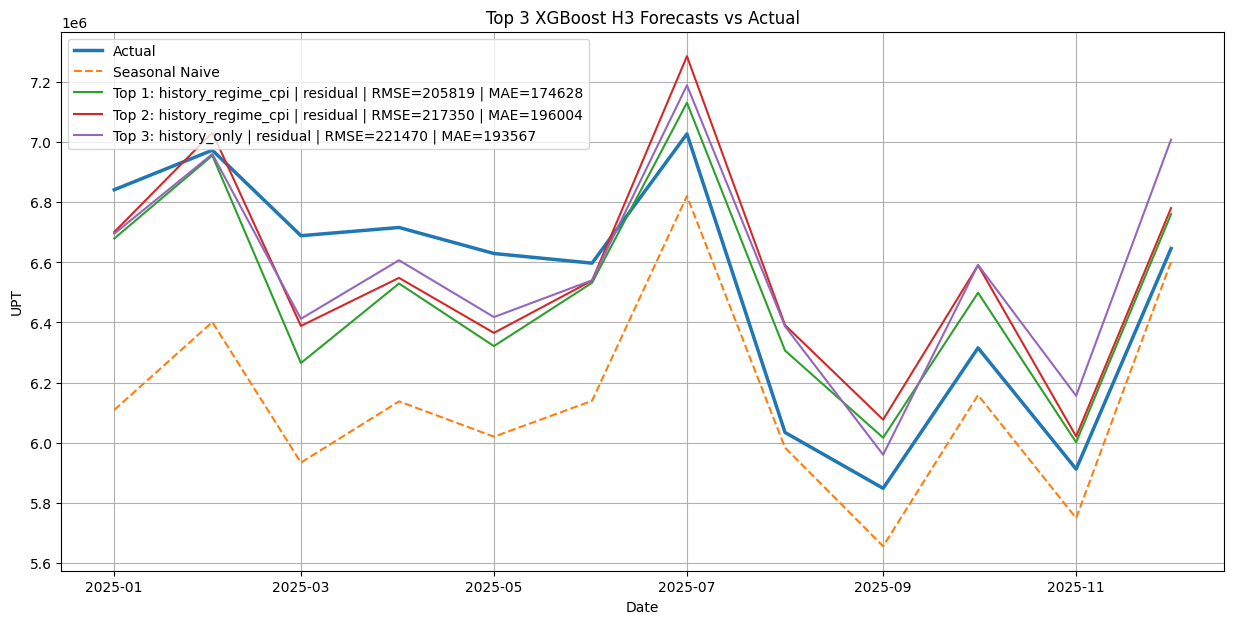

,feature_family_name,mode,rmse_valid,mae_valid,r2_valid,diracc_valid,rmse_improvement_vs_naive,mae_improvement_vs_naive
0,history_regime_cpi,residual,205818.833361,174627.765625,0.712242,0.909091,249392.438345,202165.151042
1,history_regime_cpi,residual,217350.335402,196003.807292,0.679094,0.909091,237860.936304,180789.109375
2,history_only,residual,221470.077059,193566.539062,0.666813,0.909091,233741.194646,183226.377604


In [13]:
# ---------------------------------------------------
# choose the top 3 model configurations from results_df
# ---------------------------------------------------
top3_runs = results_df.nsmallest(3, "rmse_valid").copy().reset_index(drop=True)
print(top3_runs[[
    "feature_family_name", "mode", "rmse_valid", "mae_valid", "r2_valid", "diracc_valid",
    "n_estimators", "max_depth", "learning_rate", "subsample", "colsample_bytree", "min_child_weight"
]])

# ---------------------------------------------------
# rerun those exact 3 experiments to recover forecasts
# ---------------------------------------------------
top3_outputs = []

for i, row in top3_runs.iterrows():
    family_name = row["feature_family_name"]
    mode = row["mode"]

    feature_cols = [c for c in feature_set_library[family_name] if c in feature_table_h3.columns]

    params = {
        "n_estimators": int(row["n_estimators"]),
        "max_depth": int(row["max_depth"]),
        "learning_rate": float(row["learning_rate"]),
        "subsample": float(row["subsample"]),
        "colsample_bytree": float(row["colsample_bytree"]),
        "min_child_weight": float(row["min_child_weight"]),
    }

    out = run_xgb_experiment(
        df=feature_table_h3,
        feature_cols=feature_cols,
        params=params,
        target_col="upt_target_h3",
        split_date="2025-01-01",
        mode=mode,
    )

    pred_col = f"pred_top{i+1}"
    label = (
        f"Top {i+1}: {family_name} | {mode} | "
        f"RMSE={row['rmse_valid']:.0f} | MAE={row['mae_valid']:.0f}"
    )

    forecast_df = pd.DataFrame({
        "date": pd.to_datetime(out["valid_dates"]),
        "actual": out["actual_valid"],
        pred_col: out["pred_valid"],
        "seasonal_naive_pred": out["naive_valid"],
    }).sort_values("date").reset_index(drop=True)

    top3_outputs.append({
        "forecast_df": forecast_df,
        "pred_col": pred_col,
        "label": label,
    })

# ---------------------------------------------------
# merge forecasts together on date
# ---------------------------------------------------
plot_df = top3_outputs[0]["forecast_df"][["date", "actual", "seasonal_naive_pred", top3_outputs[0]["pred_col"]]].copy()

for item in top3_outputs[1:]:
    plot_df = plot_df.merge(
        item["forecast_df"][["date", item["pred_col"]]],
        on="date",
        how="outer"
    )

plot_df = plot_df.sort_values("date").reset_index(drop=True)
print(plot_df.head(12))

# ---------------------------------------------------
# plot
# ---------------------------------------------------
plt.figure(figsize=(15, 7))
plt.plot(plot_df["date"], plot_df["actual"], label="Actual", linewidth=2.5)
plt.plot(plot_df["date"], plot_df["seasonal_naive_pred"], label="Seasonal Naive", linestyle="--")

for item in top3_outputs:
    plt.plot(plot_df["date"], plot_df[item["pred_col"]], label=item["label"])

plt.title("Top 3 XGBoost H3 Forecasts vs Actual")
plt.xlabel("Date")
plt.ylabel("UPT")
plt.legend()
plt.grid(True)
plt.show()

top3_runs[[
    "feature_family_name",
    "mode",
    "rmse_valid",
    "mae_valid",
    "r2_valid",
    "diracc_valid",
    "rmse_improvement_vs_naive",
    "mae_improvement_vs_naive",
]]


## Feature Coverage Audit

In [ ]:
all_grouped_features = sorted(set(feature_set_library["history_regime_all_exog"]))
all_possible_features = sorted([c for c in feature_table_h3.columns if c not in ["date", "upt_target_h3"]])

left_out = [c for c in all_possible_features if c not in all_grouped_features]

print("Grouped feature count:", len(all_grouped_features))
print("All possible feature count:", len(all_possible_features))
print("Left out count:", len(left_out))
print(left_out)

#also printing the columns included
print(all_grouped_features)

# -----------------------------------------
# Small add-on groups from leftover features
# -----------------------------------------
small_addon_groups = {
    "service_momentum_small": [
        "vrm_diff_lag1", "vrh_diff_lag1", "voms_diff_lag1",
        "vrm_yoy_diff", "vrh_yoy_diff", "voms_yoy_diff",
    ],

    "gas_momentum_small": [
        "seattle_gas_price_avg_diff_lag1",
        "seattle_gas_price_avg_diff_lag3",
        "seattle_gas_price_avg_yoy_diff",
        "seattle_gas_price_std_diff_lag1",
        "seattle_gas_price_std_rollmean_3",
    ],

    "cpi_momentum_small": [
        "cpi_all_items_sa_diff_lag1",
        "cpi_all_items_sa_yoy_diff",
        "cpi_core_sa_diff_lag1",
        "cpi_core_sa_yoy_diff",
    ],

    "time_trend_small": [
        "time_index_months",
    ],
}

# keep only columns that actually exist
small_addon_groups = {
    k: [c for c in v if c in feature_table_h3.columns]
    for k, v in small_addon_groups.items()
}

small_addon_groups


## Add-On Feature Combos

In [14]:
target_col = "upt_target_h3"

# --------------------------------------------------------
# set your previous best family and mode here if needed
# --------------------------------------------------------
base_family_name = "history_regime_all_exog"
base_mode = "residual"

base_feature_cols = [c for c in feature_set_library[base_family_name] if c in feature_table_h3.columns]

print("Base family:", base_family_name)
print("Base mode:", base_mode)
print("Base feature count:", len(base_feature_cols))

# --------------------------------------------------------
# build combination library:
# base only + every non-empty combination of add-on groups
# --------------------------------------------------------
addon_names = list(small_addon_groups.keys())

combo_library = {
    f"{base_family_name}__base_only": base_feature_cols
}

for r in range(1, len(addon_names) + 1):
    for combo in itertools.combinations(addon_names, r):
        combo_name = f"{base_family_name}__plus__" + "__".join(combo)

        combo_features = list(base_feature_cols)
        for addon_name in combo:
            combo_features.extend(small_addon_groups[addon_name])

        # de-duplicate while preserving order
        combo_features = list(dict.fromkeys(combo_features))
        combo_library[combo_name] = combo_features

print("Total feature-set combos:", len(combo_library))
print(list(combo_library.keys())[:10])

# --------------------------------------------------------
# same param grid you used earlier
# --------------------------------------------------------
grid_keys = list(param_grid.keys())
grid_values = list(param_grid.values())
param_combos = [dict(zip(grid_keys, vals)) for vals in itertools.product(*grid_values)]

print("Param combos:", len(param_combos))
print("Total runs:", len(combo_library) * len(param_combos))

# --------------------------------------------------------
# run experiments
# --------------------------------------------------------
addon_results = []

for combo_name, feature_cols in combo_library.items():
    feature_cols = [c for c in feature_cols if c in feature_table_h3.columns]

    for params in param_combos:
        out = run_xgb_experiment(
            df=feature_table_h3,
            feature_cols=feature_cols,
            params=params,
            target_col=target_col,
            split_date="2025-01-01",
            mode=base_mode,
        )

        addon_results.append({
            "feature_family_name": combo_name,
            "base_family_name": base_family_name,
            "mode": base_mode,
            "n_features": out["n_features"],
            "n_train": out["n_train"],
            "n_valid": out["n_valid"],
            **params,
            "mae_valid": out["mae_valid"],
            "rmse_valid": out["rmse_valid"],
            "r2_valid": out["r2_valid"],
            "diracc_valid": out["diracc_valid"],
            "mae_naive_valid": out["mae_naive_valid"],
            "rmse_naive_valid": out["rmse_naive_valid"],
            "mae_improvement_vs_naive": out["mae_naive_valid"] - out["mae_valid"],
            "rmse_improvement_vs_naive": out["rmse_naive_valid"] - out["rmse_valid"],
        })

addon_results_df = pd.DataFrame(addon_results).sort_values("rmse_valid").reset_index(drop=True)

print("\nTop 20 runs:")
display(addon_results_df.head(20))

addon_summary = (
    addon_results_df.groupby(["feature_family_name", "mode"])
    .agg(
        best_rmse=("rmse_valid", "min"),
        best_mae=("mae_valid", "min"),
        best_r2=("r2_valid", "max"),
        best_diracc=("diracc_valid", "max"),
        best_rmse_improvement_vs_naive=("rmse_improvement_vs_naive", "max"),
        best_mae_improvement_vs_naive=("mae_improvement_vs_naive", "max"),
        avg_rmse=("rmse_valid", "mean"),
        avg_mae=("mae_valid", "mean"),
    )
    .sort_values("best_rmse")
    .reset_index()
)

addon_summary


Base family: history_regime_all_exog
Base mode: residual
Base feature count: 85


NameError: name 'small_addon_groups' is not defined